In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

In [12]:
data = load_wine(as_frame=True)

df = data.frame

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [13]:
print(df.info())

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [14]:
print("Выделение признаков без target")
X = df.drop("target", axis=1)
print("Размер X:", X.shape)

Выделение признаков без target
Размер X: (178, 13)


In [15]:
print("Масштабирование данных")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

Масштабирование данных
[[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
   1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
   1.01300893]
 [ 0.24628963 -0.49941338 -0.82799632 -2.49084714  0.01814502  0.56864766
   0.73362894 -0.82071924 -0.54472099 -0.29332133  0.40605066  1.1134493
   0.96524152]
 [ 0.19687903  0.02123125  1.10933436 -0.2687382   0.08835836  0.80899739
   1.21553297 -0.49840699  2.13596773  0.26901965  0.31830389  0.78858745
   1.39514818]
 [ 1.69154964 -0.34681064  0.4879264  -0.80925118  0.93091845  2.49144552
   1.46652465 -0.98187536  1.03215473  1.18606801 -0.42754369  1.18407144
   2.33457383]
 [ 0.29570023  0.22769377  1.84040254  0.45194578  1.28198515  0.80899739
   0.66335127  0.22679555  0.40140444 -0.31927553  0.36217728  0.44960118
  -0.03787401]]


In [16]:
print("Снижение размерности с помощью PCA")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca[:5])

Снижение размерности с помощью PCA
[[ 3.31675081  1.44346263]
 [ 2.20946492 -0.33339289]
 [ 2.51674015  1.0311513 ]
 [ 3.75706561  2.75637191]
 [ 1.00890849  0.86983082]]


Построение графика PCA


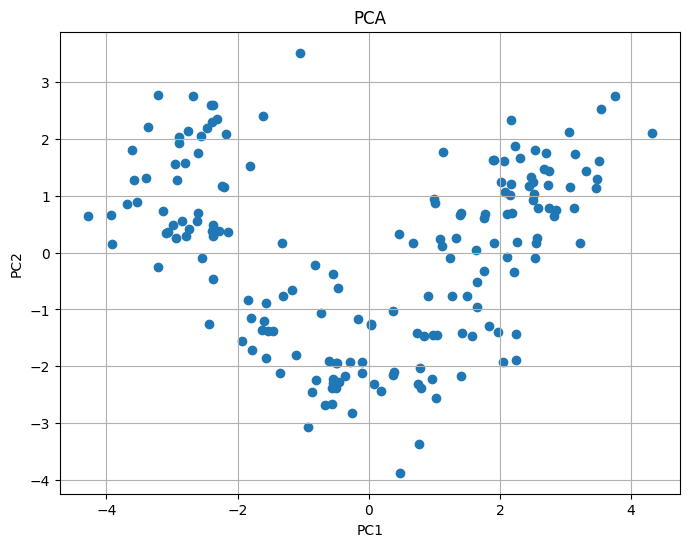

In [17]:
print("Построение графика PCA")

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)
plt.title("PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()

In [18]:
print("Снижение размерности с помощью t-SNE")
tsne = TSNE(
    n_components=2,
    random_state=42
)
X_tsne = tsne.fit_transform(X_scaled)
print(X_tsne[:5])

Снижение размерности с помощью t-SNE
[[10.9068365 -6.368669 ]
 [ 7.162088  -5.6288743]
 [ 7.936114  -9.866809 ]
 [10.758796  -9.173645 ]
 [ 3.8357487 -9.728746 ]]


Построение графика t-SNE


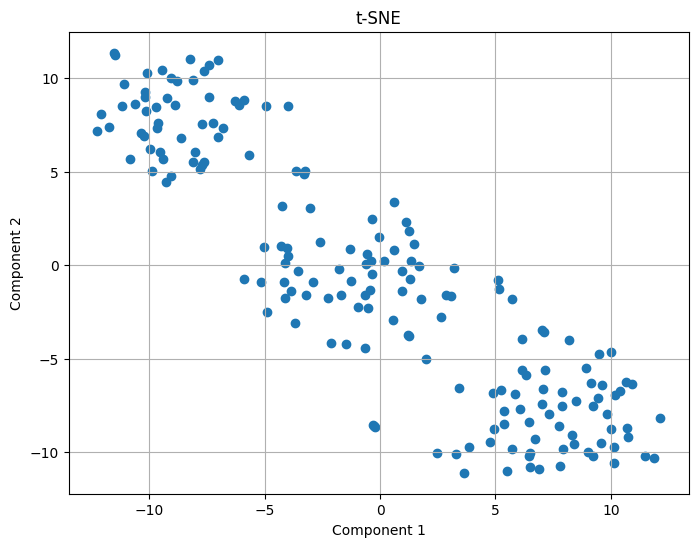

In [19]:
print("Построение графика t-SNE")
plt.figure(figsize=(8,6))
plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1]
)
plt.title("t-SNE")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid()
plt.show()

In [20]:
print("Кластеризация методом KMeans")

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)
print("Silhouette Score KMeans:", kmeans_score)

Кластеризация методом KMeans
Silhouette Score KMeans: 0.2848589191898987


In [21]:
print("Кластеризация методом Agglomerative Clustering")

agg = AgglomerativeClustering(
    n_clusters=3
)
agg_labels = agg.fit_predict(X_scaled)
agg_score = silhouette_score(
    X_scaled,
    agg_labels
)
print("Silhouette Score Agglomerative:", agg_score)

Кластеризация методом Agglomerative Clustering
Silhouette Score Agglomerative: 0.2774439826952266


In [22]:
print("Кластеризация методом DBSCAN")

dbscan = DBSCAN(
    eps=2,
    min_samples=5
)
dbscan_labels = dbscan.fit_predict(X_scaled)
dbscan_score = silhouette_score(
    X_scaled,
    dbscan_labels
)
print("Silhouette Score DBSCAN:", dbscan_score)

Кластеризация методом DBSCAN
Silhouette Score DBSCAN: -0.032906139982209724


In [23]:
print("Сравнение результатов кластеризации")

results = pd.DataFrame({
    "Метод": [
        "KMeans",
        "Agglomerative",
        "DBSCAN"
    ],
    "Silhouette Score": [
        kmeans_score,
        agg_score,
        dbscan_score
    ]
})
results

Сравнение результатов кластеризации


,Метод,Silhouette Score
0,KMeans,0.284859
1,Agglomerative,0.277444
2,DBSCAN,-0.032906


Построение графика сравнения методов


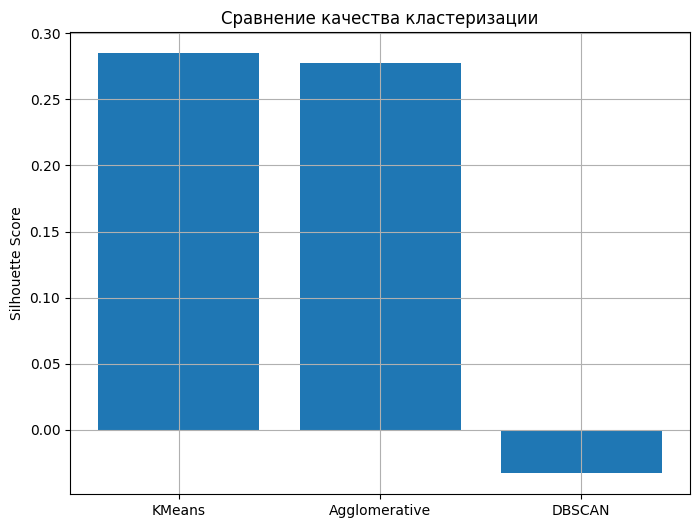

In [24]:
print("Построение графика сравнения методов")

plt.figure(figsize=(8,6))

plt.bar(
    results["Метод"],
    results["Silhouette Score"]
)
plt.title("Сравнение качества кластеризации")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

In [25]:
print("Кластеризация для D1, D2 и D3")

datasets = {
    "D1 исходные признаки": X_scaled,
    "D2 PCA": X_pca,
    "D3 t-SNE": X_tsne
}

all_results = []

for dataset_name, dataset in datasets.items():

    kmeans_labels = KMeans(n_clusters=3, random_state=42).fit_predict(dataset)
    kmeans_score = silhouette_score(dataset, kmeans_labels)

    agg_labels = AgglomerativeClustering(n_clusters=3).fit_predict(dataset)
    agg_score = silhouette_score(dataset, agg_labels)

    dbscan_labels = DBSCAN(eps=2, min_samples=5).fit_predict(dataset)

    if len(set(dbscan_labels)) > 1:
        dbscan_score = silhouette_score(dataset, dbscan_labels)
    else:
        dbscan_score = None

    all_results.append([dataset_name, "KMeans", kmeans_score])
    all_results.append([dataset_name, "Agglomerative", agg_score])
    all_results.append([dataset_name, "DBSCAN", dbscan_score])

all_results_df = pd.DataFrame(
    all_results,
    columns=["Датасет", "Метод", "Silhouette Score"]
)

all_results_df

Кластеризация для D1, D2 и D3


,Датасет,Метод,Silhouette Score
0,D1 исходные признаки,KMeans,0.284859
1,D1 исходные признаки,Agglomerative,0.277444
2,D1 исходные признаки,DBSCAN,-0.032906
3,D2 PCA,KMeans,0.560170
4,D2 PCA,Agglomerative,0.559088
5,D2 PCA,DBSCAN,NaN
6,D3 t-SNE,KMeans,0.603749
7,D3 t-SNE,Agglomerative,0.577057
8,D3 t-SNE,DBSCAN,0.521116


График сравнения методов для D1, D2 и D3


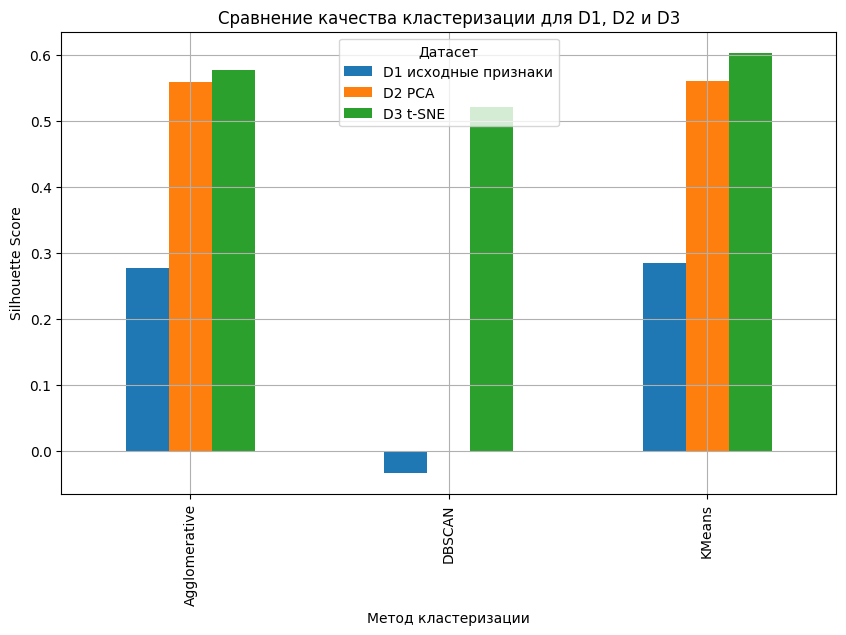

In [26]:
print("График сравнения методов для D1, D2 и D3")

pivot_results = all_results_df.pivot(
    index="Метод",
    columns="Датасет",
    values="Silhouette Score"
)

pivot_results.plot(kind="bar", figsize=(10, 6))

plt.title("Сравнение качества кластеризации для D1, D2 и D3")
plt.ylabel("Silhouette Score")
plt.xlabel("Метод кластеризации")
plt.grid()

plt.show()

In [27]:
print("""
По результатам кластеризации видно, что снижение размерности улучшило качество выделения кластеров.

На исходных данных D1 методы KMeans и Agglomerative Clustering показали близкие результаты,
однако значения Silhouette Score оказались сравнительно низкими.

После снижения размерности с помощью PCA качество кластеризации заметно улучшилось.
Методы KMeans и Agglomerative Clustering показали Silhouette Score около 0.56.

Наилучший результат был получен для данных D3, сформированных методом t-SNE.
Метод KMeans показал Silhouette Score = 0.6037, что является лучшим результатом среди всех экспериментов.

DBSCAN хуже сработал на исходных данных D1 и не смог корректно выделить кластеры на D2,
но на данных D3 t-SNE показал приемлемый результат.

Таким образом, наиболее явно кластеры выделяются после применения t-SNE,
а лучшим методом кластеризации для данного набора данных оказался KMeans на датасете D3.
""")


По результатам кластеризации видно, что снижение размерности улучшило качество выделения кластеров.

На исходных данных D1 методы KMeans и Agglomerative Clustering показали близкие результаты,
однако значения Silhouette Score оказались сравнительно низкими.

После снижения размерности с помощью PCA качество кластеризации заметно улучшилось.
Методы KMeans и Agglomerative Clustering показали Silhouette Score около 0.56.

Наилучший результат был получен для данных D3, сформированных методом t-SNE.
Метод KMeans показал Silhouette Score = 0.6037, что является лучшим результатом среди всех экспериментов.

DBSCAN хуже сработал на исходных данных D1 и не смог корректно выделить кластеры на D2,
но на данных D3 t-SNE показал приемлемый результат.

Таким образом, наиболее явно кластеры выделяются после применения t-SNE,
а лучшим методом кластеризации для данного набора данных оказался KMeans на датасете D3.

